# Grover's Search Algorithm


Grover's algorithm is a quantum algorithm designed to solve the unstructured search problem with a quadratic speedup. The algorithm is based on quantum superposition and interference-based amplitude amplification. \
For example, let us analyze Grover's search algorithm and try to find one marked state - $|1011\rangle$


### Initial state

First, all qubits are prepared in an equal superposition:
$$
|s\rangle = \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} |x\rangle.
$$

In the case of four qubits, \(N = 16\), and for each state, including $|1011\rangle$
, the initial amplitude is $\frac{1}{\sqrt{16}} = \frac{1}{4}.$

### Oracle

The oracle is a quantum operator that recognizes the marked state and flips its phase. If we are searching for the state $|1011\rangle$, the action of the oracle is:
$$
O|x\rangle =
\begin{cases}
-|x\rangle, & \text{if } x = 1011 \\
\;\;\;|x\rangle, & \text{otherwise}
\end{cases}
$$

After applying the oracle, only the amplitude of the state $|1011\rangle$ becomes negative, while the amplitudes of all other states remain unchanged. At this point, the measurement probabilities still do not change, but the phase change is essential for the next step.

### Diffusion operator

The next step is the diffusion operator: $D = 2|s\rangle\langle s| - I,$
where $I$ is the identity operator. The diffusion operator reflects the amplitudes about the average value.

Since after the oracle the amplitude of the state $|1011\rangle$ is below the average value (negative), the diffusion operator raises it above the average level, while the amplitudes of all other states are slightly reduced.

### Grover iteration

The combination of the oracle and the diffusion operator forms one Grover iteration: $G = D O.$

Mathematically, it can be shown that this iteration corresponds to a rotation of the quantum state in a two-dimensional subspace determined by:
- the marked state $|1011\rangle$,
- the superposition of all unmarked states.

Each iteration rotates the state by a fixed angle $2\theta$, where $\sin\theta = \frac{1}{\sqrt{N}}.$

In the case of four qubits:
$
\sin\theta = \frac{1}{4}.
$


### Number of iterations



The optimal number of Grover iterations in the case of one marked state is:
$$
k \approx \frac{\pi}{4}\sqrt{N}.
$$

Therefore:
$$
k \approx \frac{\pi}{4}\sqrt{16} = \pi \approx 3.
$$

After three Grover iterations, the amplitude of the state $|1011\rangle$ is very close to 1, while the amplitudes of all other states are close to zero.

### Measurement

Finally, a quantum measurement is performed. Since the probability of the state $|1011\rangle$ is dominant, the measurement result with very high probability will be exactly the bit string 1011.

### Summary

Grover's algorithm does not find the correct state directly, but gradually amplifies its amplitude using phase inversion and quantum interference.

# High-Level Grover Search Algorithm

* The quantum circuit is not constructed

* The oracle is described logically

* The number of iterations is chosen by Qiskit

* The ancilla is hidden

In [2]:
%pip install qiskit qiskit-algorithms

  Using cached qiskit_algorithms-0.4.0-py3-none-any.whl.metadata (4.7 kB)
Using cached qiskit_algorithms-0.4.0-py3-none-any.whl (327 kB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
from qiskit_algorithms import Grover, AmplificationProblem
from qiskit.circuit.library import PhaseOracleGate
from qiskit.primitives import StatevectorSampler


# Target state, in this example |1011>
target_state = "1011"

# Oracle definition
# q3 = 1, q2 = 0, q1 = 1, q0 = 1
oracle_expression = "(q3 & ~q2 & q1 & q0 )"
oracle = PhaseOracleGate(oracle_expression)


# Defining the Grover problem
# Qiskit returns measurement results in reverse order

problem = AmplificationProblem(
    oracle=oracle,
    is_good_state=lambda bitstring: bitstring[::-1] == target_state
)

# Initializing the Grover algorithm
sampler = StatevectorSampler()
grover = Grover(sampler=sampler)


# Executing the Grover algorithm
result = grover.amplify(problem)


# Printing the results
print("Top measurement (Qiskit bit order q0 q1 q2 q3):",
      result.top_measurement)

print("Top measurement (logical order |q3 q2 q1 q0>):",
      result.top_measurement[::-1])

Top measurement (Qiskit bit order q0 q1 q2 q3): 1101
Top measurement (logical order |q3 q2 q1 q0>): 1011


# Low-Level Grover Search Algorithm
* the quantum circuit is built using gates

* the oracle and diffusion are visible

* the ancilla is used directly

* the number of iterations is controlled by the user

Measurement results:
0000 : 59
0001 : 80
0010 : 53
0011 : 54
0100 : 64
0101 : 63
0110 : 67
0111 : 54
1000 : 64
1001 : 54
1010 : 70
1011 : 54
1100 : 84
1101 : 9051
1110 : 60
1111 : 69


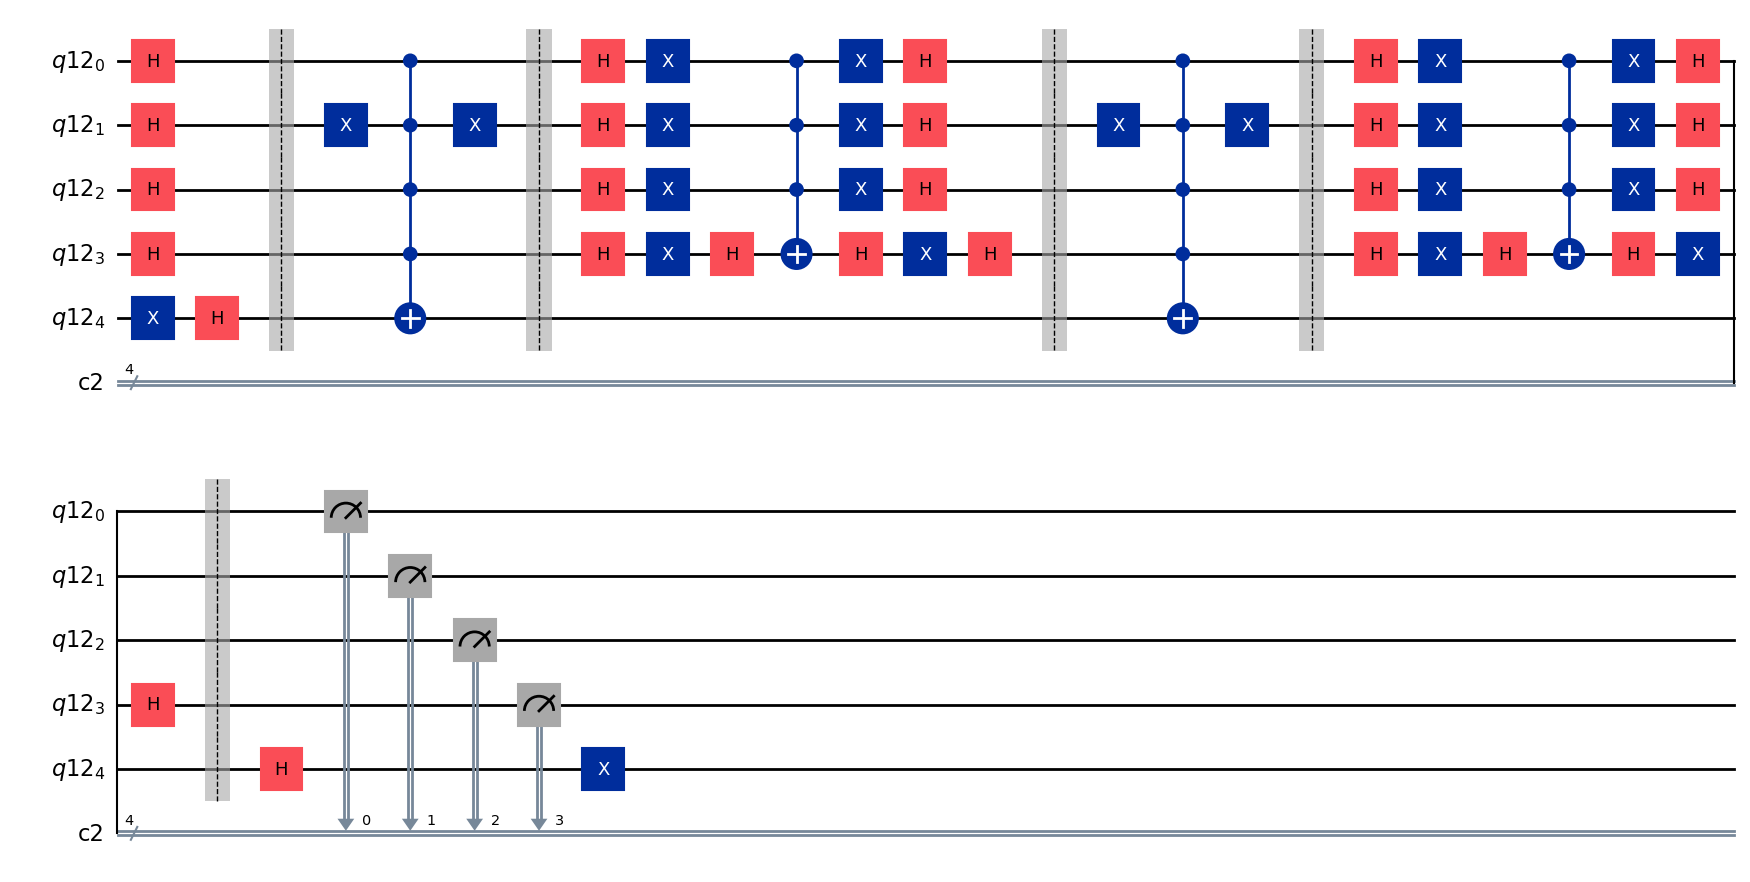

In [5]:
# Grover Search: 4 search qubits + 1 ancilla qubit
# Target state: |1011>

from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import AerSimulator

n_search = 4                 # number of search qubits
target_state = "1011"        # target state to search for
grover_iterations = 2        # number of Grover iterations, 2 – good result, 6 – visible overshooting
shots = 10000                

qreg = QuantumRegister(n_search + 1) # The last qubit is used as an ancilla
creg = ClassicalRegister(n_search)
qc = QuantumCircuit(qreg, creg)

# Initialize the ancilla in the state |-> = (|0> - |1>)/√2
# Needed for phase kickback implementation
qc.x(qreg[n_search])
qc.h(qreg[n_search])

# Put the search qubits into superposition
for i in range(n_search):
    qc.h(qreg[i])

qc.barrier()

# Oracle definition
# Flips the phase exactly for the state |1011>
def oracle(circuit, q):
    # Invert those qubits that are 0 in the target state
    for i, bit in enumerate(target_state):
        if bit == "0":
            circuit.x(q[i])

    # Multi-controlled NOT on the ancilla qubit
    # implements phase flip using phase kickback
    circuit.mcx(q[:n_search], q[n_search])

    # Return the inverted qubits to their original state
    for i, bit in enumerate(target_state):
        if bit == "0":
            circuit.x(q[i])


# Diffusion operator (inversion about the mean)
# Amplifies the amplitude of the target state
def diffusion(circuit, q):
    # Hadamard and X gates on the search qubits
    for i in range(n_search):
        circuit.h(q[i])
        circuit.x(q[i])

    # Multi-controlled Z gate (implemented with MCX)
    circuit.h(q[n_search - 1])
    circuit.mcx(q[:n_search - 1], q[n_search - 1])
    circuit.h(q[n_search - 1])

    for i in range(n_search):
        circuit.x(q[i])
        circuit.h(q[i])


# Grover iterations
for _ in range(grover_iterations):
    oracle(qc, qreg)
    qc.barrier()
    diffusion(qc, qreg)
    qc.barrier()


# Return the ancilla qubit to the initial state |0>
qc.h(qreg[n_search])
qc.x(qreg[n_search])


# Measurements of the search qubits
for i in range(n_search):
    qc.measure(qreg[i], creg[i])



sim = AerSimulator()
job = sim.run(qc, shots=shots)
counts = job.result().get_counts()

print("Measurement results:")
for outcome in sorted(counts):
    print(outcome, ":", counts[outcome])

qc.draw(output='mpl')